# This notebooks calculates the agreement of snowy days between different datasets

In [19]:
import pandas as pd
from timeseries_utils import read_daily_timeseries_csv

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 300
#plt.style.use('dark_background') # The black backgrounds were used for presentations, journal required white background
plt.rcParams.update({'font.size': 10})
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
swe_era5_path = '/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/swe.csv'
swe_cci_path = '/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/swe_cci3-1.csv'
snow_depth = '/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/snow_depth.csv'

paths = {'swe_era5': swe_era5_path, 'swe_cci': swe_cci_path, 'snow_depth':snow_depth}

In [3]:
# for sorting the catchments
clim_attrs = pd.read_csv('/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_climatic_attributes.csv', index_col=0)
mean_tmp = clim_attrs['temperature_mean']

In [4]:
data = {}
for name in paths:
    values = read_daily_timeseries_csv(paths[name])
    values = values.loc["1990-09-01":"2020-08-31"]
    data[name] = (values > 1.0).sum()
    
data = pd.DataFrame(data)
day_count = len(values)

data

,swe_era5,swe_cci,snow_depth
896,5814,4872,4856
905,6182,5355,5629
907,6123,5385,5525
908,6117,5375,5550
923,5961,4851,5345
...,...,...,...
3727,6534,5776,5898
3728,6477,5835,5909
3850,5262,4264,4024
3907,4277,3365,3498


In [6]:
day_count

10958

In [9]:
snow_days = data / 30 # calculating the amount of snow days per year, there are 30 years
snow_days = snow_days.join(mean_tmp)
snow_days = snow_days.sort_values('temperature_mean', ascending=False) # for more intuitive plots
snow_days

,swe_era5,swe_cci,snow_depth,temperature_mean
3524,135.300000,87.566667,119.933333,5.99
3006,144.300000,101.800000,120.133333,5.95
1100,144.633333,115.333333,127.266667,5.82
1120,140.066667,114.633333,103.766667,5.81
3678,141.633333,99.700000,114.800000,5.81
...,...,...,...,...
1413,233.833333,204.666667,210.466667,-0.91
1374,236.366667,212.466667,215.733333,-0.92
1373,233.233333,211.266667,213.400000,-1.01
1411,238.433333,209.266667,212.200000,-1.15


In [11]:
# temperature is no longer needed after sorting
snow_days = snow_days[paths.keys()]
snow_days

,swe_era5,swe_cci,snow_depth
3524,135.300000,87.566667,119.933333
3006,144.300000,101.800000,120.133333
1100,144.633333,115.333333,127.266667
1120,140.066667,114.633333,103.766667
3678,141.633333,99.700000,114.800000
...,...,...,...
1413,233.833333,204.666667,210.466667
1374,236.366667,212.466667,215.733333
1373,233.233333,211.266667,213.400000
1411,238.433333,209.266667,212.200000


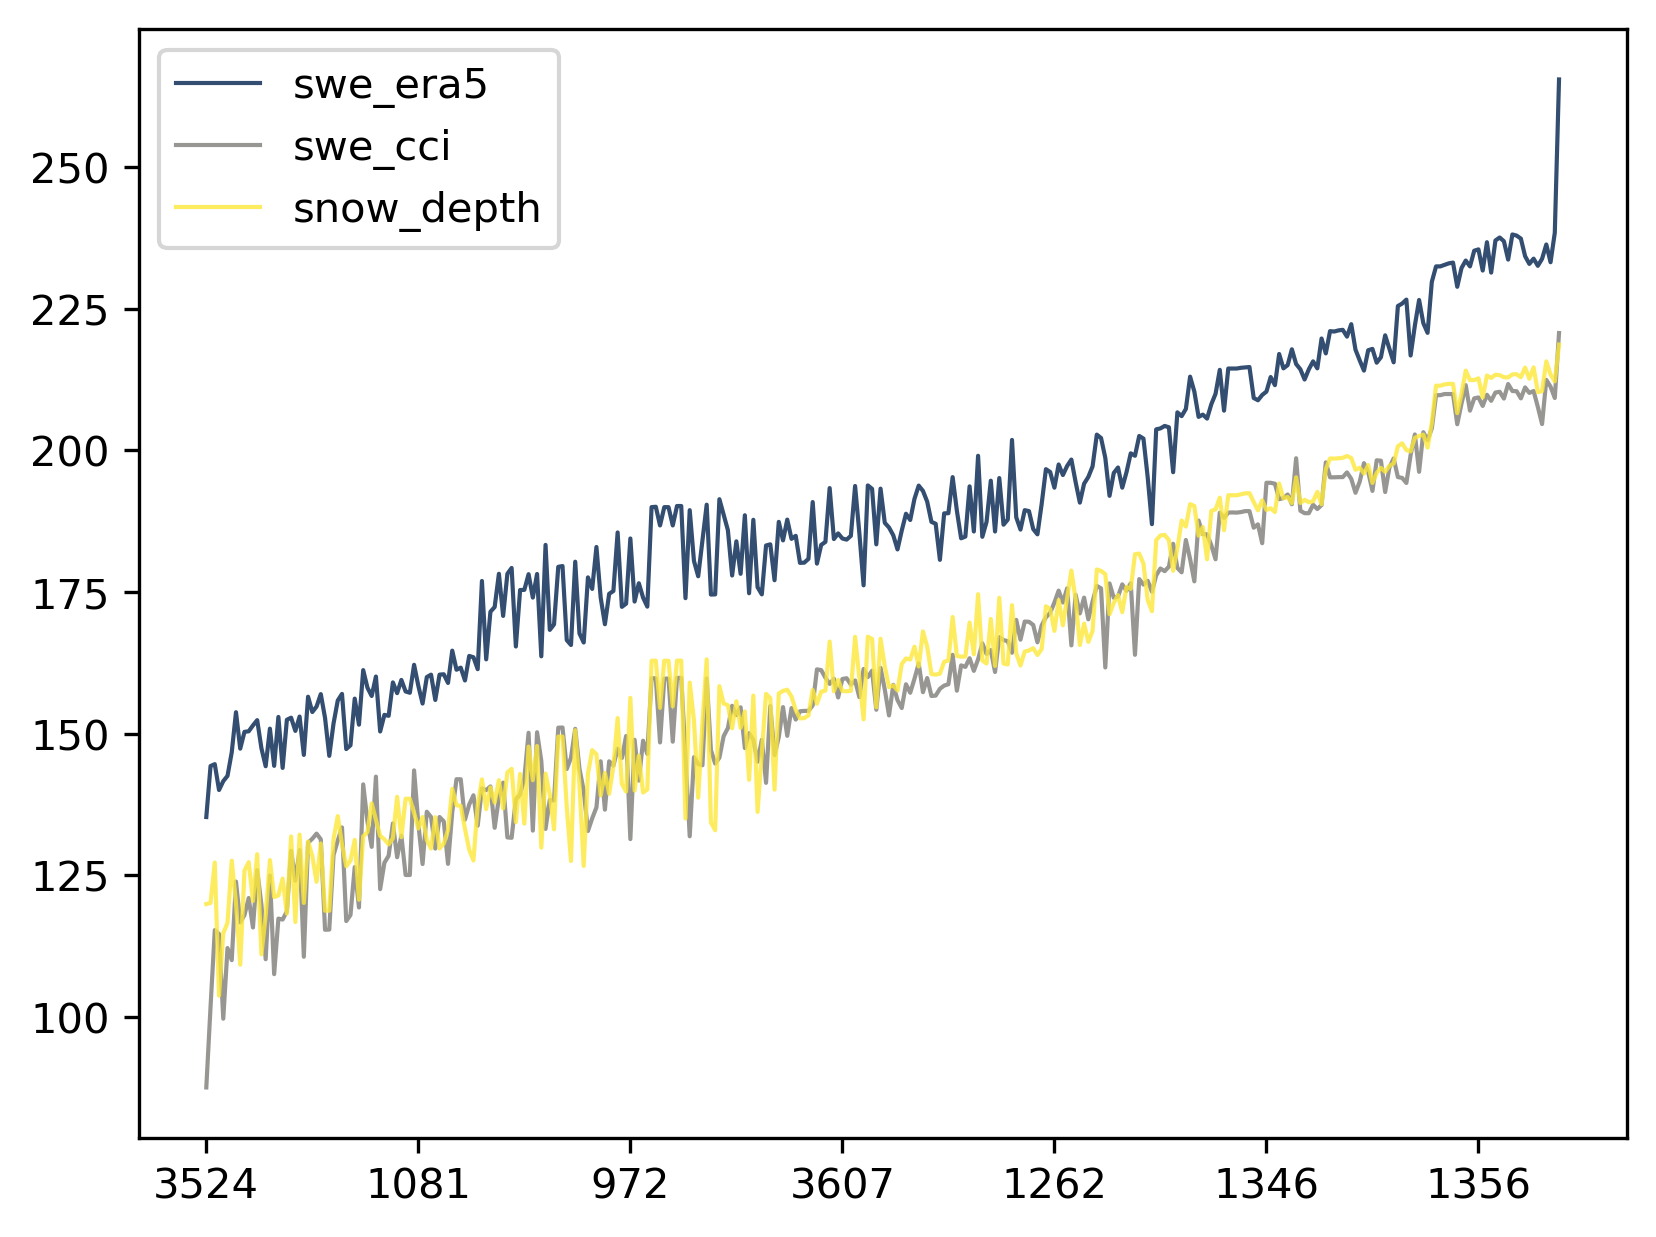

In [25]:

ax = snow_days.plot(cmap='cividis', linewidth=1, alpha=0.8)

<Axes: >

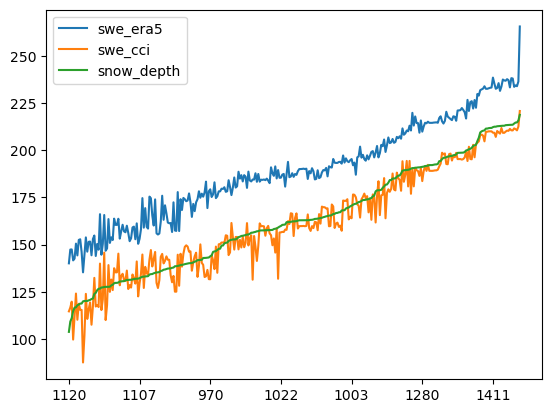

In [14]:
snow_days.plot()

In [13]:
diff = pd.DataFrame(index=snow_days.index)
compared = {} 
# Going trough the differences between datasets
for ds_1 in snow_days.columns:
    for ds_2 in snow_days.columns:
        if ds_1 == ds_2: # Skipping comparing dataset to itself
            continue
        if f'{ds_2}-{ds_1}' in diff.columns: # skipping duplicates
            continue
        diff[f'{ds_1}-{ds_2}'] = snow_days[ds_1] - snow_days[ds_2]
        

In [14]:
diff

,swe_era5-swe_cci,swe_era5-snow_depth,swe_cci-snow_depth
3524,47.733333,15.366667,-32.366667
3006,42.500000,24.166667,-18.333333
1100,29.300000,17.366667,-11.933333
1120,25.433333,36.300000,10.866667
3678,41.933333,26.833333,-15.100000
...,...,...,...
1413,29.166667,23.366667,-5.800000
1374,23.900000,20.633333,-3.266667
1373,21.966667,19.833333,-2.133333
1411,29.166667,26.233333,-2.933333


<Axes: >

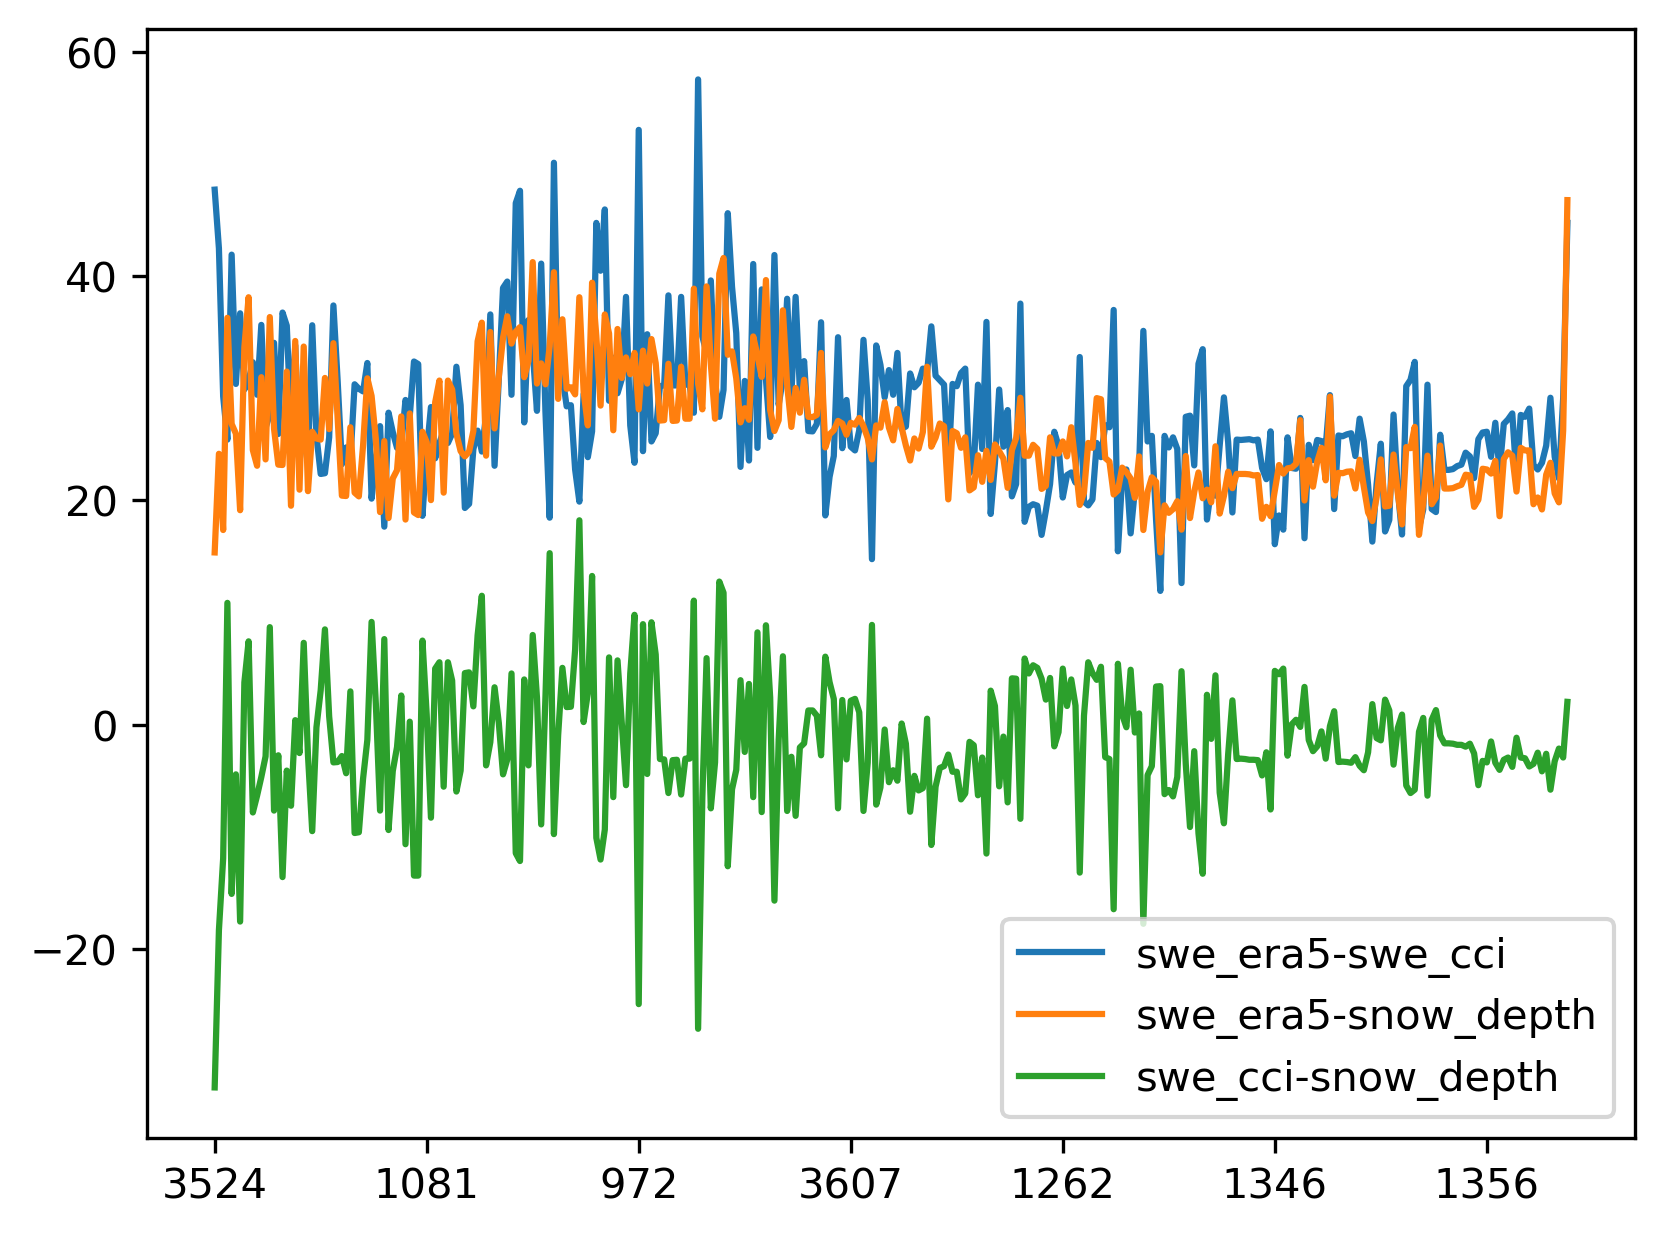

In [26]:
diff.plot()

In [15]:
diff.mean()

swe_era5-swe_cci       27.546354
swe_era5-snow_depth    25.785833
swe_cci-snow_depth     -1.760521
dtype: float64

In [16]:
diff.median()

swe_era5-swe_cci       26.216667
swe_era5-snow_depth    24.783333
swe_cci-snow_depth     -2.466667
dtype: float64

In [17]:
snow_days.mean()

swe_era5      189.428854
swe_cci       161.882500
snow_depth    163.643021
dtype: float64

In [18]:
snow_days.median()

swe_era5      187.566667
swe_cci       159.716667
snow_depth    162.350000
dtype: float64

In [27]:
diff.std()

swe_era5-swe_cci       6.779063
swe_era5-snow_depth    5.393461
swe_cci-snow_depth     6.351460
dtype: float64